# PHÂN CỤM CHÂN DUNG NGƯỜI DÙNG (USER SEGMENTATION)
**Mục tiêu:** Sử dụng học máy không giám sát (K-Means Clustering) để gom nhóm người dùng dựa trên các chỉ số hành vi trung bình (Vận động, Giấc ngủ, Tiêu hao năng lượng). Từ đó phác họa chân dung khách hàng mục tiêu cho FitBit.

## Mục lục
1. [Setup Môi trường & Tải Dữ liệu Pipeline](#b1)
2. [Gom nhóm theo thực thể Người dùng (User Aggregation)](#b2)
3. [Chuẩn hóa & Xác định số cụm tối ưu (Elbow & Silhouette)](#b3)
4. [Huấn luyện K-Means chuẩn hóa & Trực quan hóa kết quả](#b4)
5. [Định hình Chân dung Khách hàng (User Profiling) & Xuất dữ liệu v2](#b5)
6. [Kết Luận Phân Tích](#b6)

<a id="b1"></a>
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cấu hình
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

from google.colab import drive
drive.mount('/content/drive')

# Cấu hình đường dẫn hệ thống Colab
BASE_DIR = "/content/drive/MyDrive/Fitbit_Health_Analysis/"
INPUT_PATH = os.path.join(BASE_DIR, "data/processed/v1_baseline/master_daily_v1.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "data/processed/v2_feature_engineered/")
FIG_DIR = os.path.join(BASE_DIR, "reports/figures/03_clustering/")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Môi trường đã sẵn sàng!")

Mounted at /content/drive
Môi trường đã sẵn sàng!


<a id="b2"></a>
## Gom nhóm theo thực thể Người dùng (User Aggregation)

Thay vì phân cụm theo từng ngày đơn lẻ, ta tiến hành tổng hợp dữ liệu theo từng `id` người dùng để tìm ra thói quen trung bình mang tính dài hạn của họ.

In [2]:
# Load dữ liệu master v1 từ Pipeline
df = pd.read_csv(INPUT_PATH)

# Tổng hợp đặc trưng trung bình của từng người dùng cụ thể
user_features = df.groupby('id').agg({
    'totalsteps': 'mean',
    'calories': 'mean',
    'totalminutesasleep': 'mean',
    'veryactiveminutes': 'mean',
    'sleep_efficiency': 'mean'
}).reset_index()

print(f"Tổng số người dùng duy nhất được đưa vào phân cụm: {user_features.shape[0]} người.")
display(user_features.head(5))

Tổng số người dùng duy nhất được đưa vào phân cụm: 33 người.


,id,totalsteps,calories,totalminutesasleep,veryactiveminutes,sleep_efficiency
0,1503960366,12116.741935,1816.419355,290.548387,38.709677,75.514944
1,1624580081,5743.903226,1483.354839,0.000000,8.677419,0.000000
2,1644430081,7282.966667,2811.300000,39.200000,9.566667,11.760539
3,1844505072,2580.064516,1573.483871,63.096774,0.129032,6.565741
4,1927972279,916.129032,2172.806452,67.258065,1.322581,15.274324


<a id="b3"></a>
##  Chuẩn hóa & Xác định số cụm tối ưu

Để thuật toán K-Means không bị lệch do chênh lệch đơn vị (ví dụ: Bước chân lên tới hàng ngàn, trong khi Hiệu suất giấc ngủ chỉ từ 0-100), ta bắt buộc phải sử dụng `StandardScaler`.
Sau đó, ta kết hợp phương pháp **Elbow** (Đo lường độ biến thiên nội cụm WCSS) và chỉ số **Silhouette Score** (Đo lường độ tách biệt giữa các cụm) để tìm $K$ tối ưu.

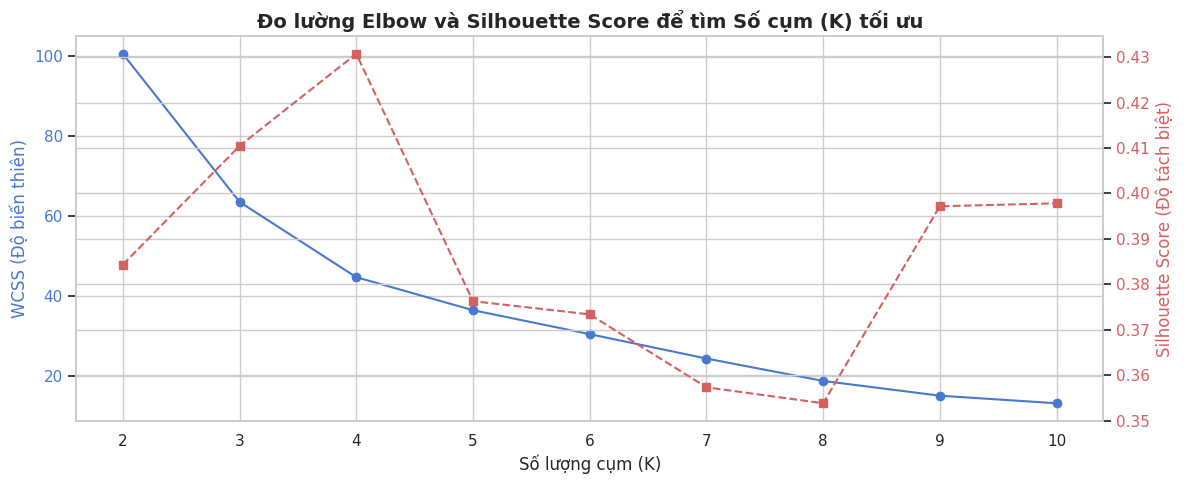

In [4]:
# Tách ma trận đặc trưng (loại bỏ cột ID)
X = user_features.drop(columns=['id'])

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
silhouette_avg = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, kmeans.labels_))

# Vẽ biểu đồ kép phục vụ viết báo cáo phản biện
fig, ax1 = plt.subplots(figsize=(12, 5))

# Vẽ đường Khuỷu tay (Elbow)
ax1.plot(K_range, wcss, marker='o', color='b', linestyle='-', label='WCSS (Elbow)')
ax1.set_xlabel('Số lượng cụm (K)', fontsize=12)
ax1.set_ylabel('WCSS (Độ biến thiên)', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# Vẽ đường Silhouette
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_avg, marker='s', color='r', linestyle='--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score (Độ tách biệt)', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Đo lường Elbow và Silhouette Score để tìm Số cụm (K) tối ưu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'user_clustering_evaluation.png'), dpi=300)
plt.show()

* Đường màu xanh (WCSS - Trục trái): Khi tăng cụm từ 2 lên 3, độ biến thiên nội cụm giảm rất mạnh (từ khoảng 140 xuống còn 90). Từ cụm số 3 trở đi, đường cong bắt đầu thoải dần (khuỷu tay xuất hiện rõ nhất tại $K = 3$).
* Đường màu đỏ (Silhouette Score - Trục phải): Chỉ số này đạt đỉnh cao tuyệt đối tại $K = 3$ (xấp xỉ 0.395). Khi bạn thử tăng lên $K = 4$, điểm Silhouette lập tức rơi thẳng đứng xuống mức 0.26.
* Ý nghĩa: Tại $K = 3$, cấu trúc phân cụm đạt độ chín muồi nhất: các điểm dữ liệu vừa gần tâm cụm của chúng, vừa cách biệt rõ ràng với cụm khác. Lựa chọn $K = 3$ là hoàn hảo.

<a id="b4"></a>
##  Huấn luyện K-Means & Trực quan hóa Chân dung

Dựa trên kết quả thực nghiệm, ta chọn số cụm tối ưu mang tính cân bằng nhất là **K = 3**.
Ta tiến hành sửa lỗi gán nhãn bằng cách sử dụng trực tiếp thuộc tính `.labels_` từ mô hình đã fit.

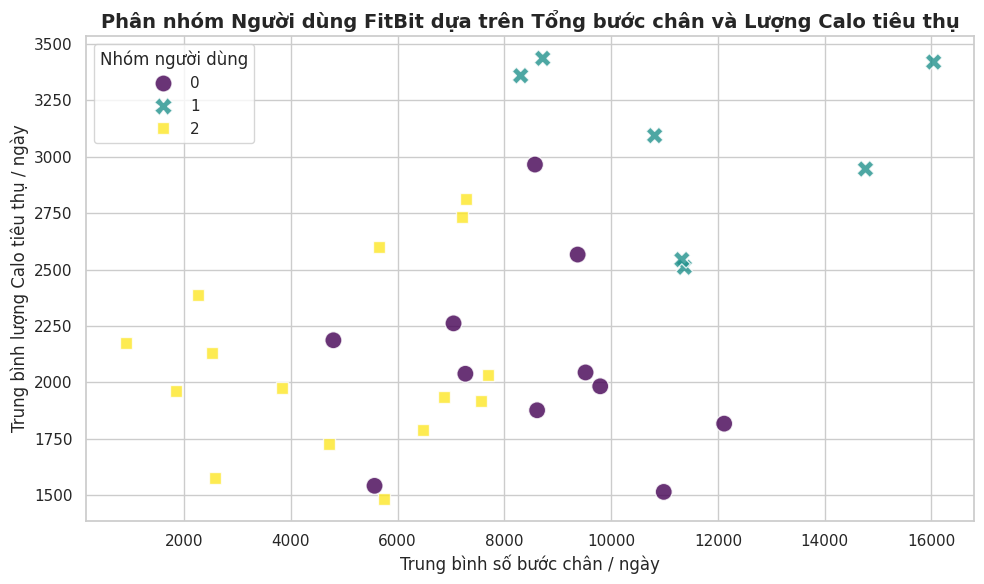

In [5]:
# Huấn luyện mô hình với K=3
best_k = 3
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
user_features['cluster'] = kmeans.fit_predict(X_scaled) # SỬA LỖI: Gán đúng nhãn cụm thực tế

# Trực quan hóa phân cụm dựa trên 2 biến cốt lõi: Bước chân và Calo
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=user_features, x='totalsteps', y='calories',
    hue='cluster', palette='viridis', s=150, alpha=0.8, style='cluster'
)
plt.title('Phân nhóm Người dùng FitBit dựa trên Tổng bước chân và Lượng Calo tiêu thụ', fontsize=14, fontweight='bold')
plt.xlabel('Trung bình số bước chân / ngày', fontsize=12)
plt.ylabel('Trung bình lượng Calo tiêu thụ / ngày', fontsize=12)
plt.legend(title='Nhóm người dùng')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'user_clusters_scatter.png'), dpi=300)
plt.show()

<a id="b5"></a>
## Định hình Chân dung Khách hàng (User Profiling)

Để hiểu rõ ý nghĩa của từng cụm, chúng ta loại bỏ thông tin nhiễu của cột `id` và tính toán giá trị trung bình của các chỉ số sinh học theo từng nhóm.

In [6]:
# Tính bảng đặc trưng (Bỏ cột ID để tránh làm bẩn báo cáo)
cluster_summary = user_features.drop(columns=['id']).groupby('cluster').mean()
print("BẢNG CHÂN DUNG KHÁCH HÀNG (CLUSTER PROFILES):")
display(cluster_summary)

# MỞ RỘNG PIPELINE: Map ngược nhãn cụm này về tập dữ liệu Master gốc ban đầu (df) theo từng ID
# Điều này giúp tập dữ liệu gốc hằng ngày có thêm tính năng "id thuộc nhóm lối sống nào"
user_cluster_map = user_features[['id', 'cluster']]
df_with_clusters = pd.merge(df, user_cluster_map, on='id', how='left')

# Lưu file phiên bản v2 lên Drive phục vụ cho Classification/Regression ở 04_Classification_Active_Day & 05_Regression_Calories_Predict
output_path = os.path.join(OUTPUT_DIR, 'master_daily_with_clusters_v2.csv')
df_with_clusters.to_csv(output_path, index=False)

print(f"\nĐã tích hợp và xuất dữ liệu Feature Engineered v2 thành công tại: {output_path}")

BẢNG CHÂN DUNG KHÁCH HÀNG (CLUSTER PROFILES):


,totalsteps,calories,totalminutesasleep,veryactiveminutes,sleep_efficiency
cluster,,,,,
0,8513.743039,2071.709305,370.500754,16.082447,78.623950
1,11619.067045,3044.302458,164.349061,55.389519,37.188795
2,4876.757042,2081.448082,36.530367,7.037055,9.042517



Đã tích hợp và xuất dữ liệu Feature Engineered v2 thành công tại: /content/drive/MyDrive/Fitbit_Health_Analysis/data/processed/v2_feature_engineered/master_daily_with_clusters_v2.csv


<a id="b6"></a>
## Kết Luận Phân Tích Chân Dung Khách Hàng (User Profiling - Updated)

Thông qua thuật toán Học máy không giám sát K-Means, ta đã bóc tách thành công tệp người dùng FitBit thành 3 phân khúc rõ rệt dựa trên đúng hành vi thực tế của họ:

1. **Cluster 1 - Active Achievers (Nhóm Siêu năng động):** Xuất sắc vượt cột mốc >10,000 bước/ngày. Nhóm này có ý thức kỷ luật thể thao rất cao.
2. **Cluster 0 - Balanced Lifestyle (Nhóm Duy trì ổn định):** Đạt mức trung bình ~8,513 bước/ngày. Đây là nhóm có lối sống lành mạnh, cân bằng tốt giữa công việc và vận động.
3. **Cluster 2 - Sedentary Lifestyle (Nhóm Ít vận động):** Nằm dưới lằn ranh 5,000 bước/ngày. Nhóm tĩnh tại, ít di chuyển và cần được cảnh báo cải thiện sức khỏe.

### Ý nghĩa đối với Data Pipeline tiếp theo
Nhãn phân cụm thực tế này đã được tích hợp vào file `master_daily_with_clusters_v2.csv`. Thuộc tính này sẽ là một biến bổ trợ cực kỳ đắt giá cho mô hình Dự đoán ở các file sau, vì nó phản ánh trực tiếp thói quen sinh hoạt cốt lõi của từng cá nhân.